In [47]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

np.random.seed(42)
print("✅ Ready")


✅ Ready


In [48]:
class HeartEngine:
    def __init__(self, fs=125):
        self.fs = fs
        self.buffer = deque()

    def generate_beat(self, target_hr):
        amplitude = np.random.normal(1.2, 0.05)
        qrs_width = np.random.normal(0.01, 0.001)

        hr_var = np.random.normal(target_hr, 3.0)
        sec_per_beat = 60.0 / hr_var
        samples = int(self.fs * sec_per_beat)

        t = np.linspace(0, sec_per_beat, samples)
        beat = np.zeros_like(t)

        beat += 0.15 * np.exp(-((t-0.2)/0.03)**2)       # P
        beat -= 0.15 * np.exp(-((t-0.28)/0.015)**2)    # Q
        beat += amplitude * np.exp(-((t-0.3)/qrs_width)**2)  # R
        beat -= 0.30 * np.exp(-((t-0.32)/0.02)**2)     # S
        beat += 0.35 * np.exp(-((t-0.45)/0.05)**2)     # T

        return beat

    def get_signal(self, duration_sec, hr=75):
        total_samples = int(self.fs * duration_sec)
        signal = []

        while len(signal) < total_samples:
            beat = self.generate_beat(hr)
            signal.extend(beat)

        signal = np.array(signal[:total_samples])

        # biological noise
        noise = np.random.normal(0, 0.03, len(signal))
        wander = 0.1 * np.sin(2*np.pi*0.25*np.arange(len(signal))/self.fs)

        return signal + noise + wander


In [49]:
def attack_rate_tamper(signal, fs):
    engine = HeartEngine(fs)
    return engine.get_signal(len(signal)/fs, hr=150)

def attack_injection(signal):
    return np.ones_like(signal) * 3.0

def attack_replay(signal, fs):
    start = np.random.randint(0, len(signal)//2)
    return signal[start:start+len(signal)]

def attack_flatline(signal):
    return np.zeros_like(signal)


In [50]:
FS = 125
DURATION = 300  # seconds (5 min)

engine = HeartEngine(FS)

# Normal ECG
ecg_normal = engine.get_signal(DURATION, hr=75)

# Attacks
ecg_rt  = attack_rate_tamper(ecg_normal, FS)
ecg_inj = attack_injection(ecg_normal)
ecg_rep = attack_replay(ecg_normal, FS)

print("Normal:", ecg_normal.shape)


Normal: (37500,)


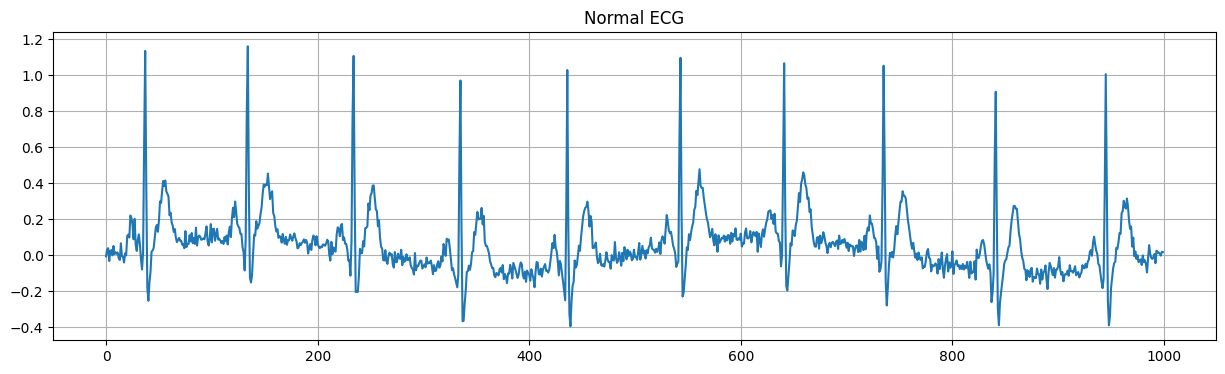

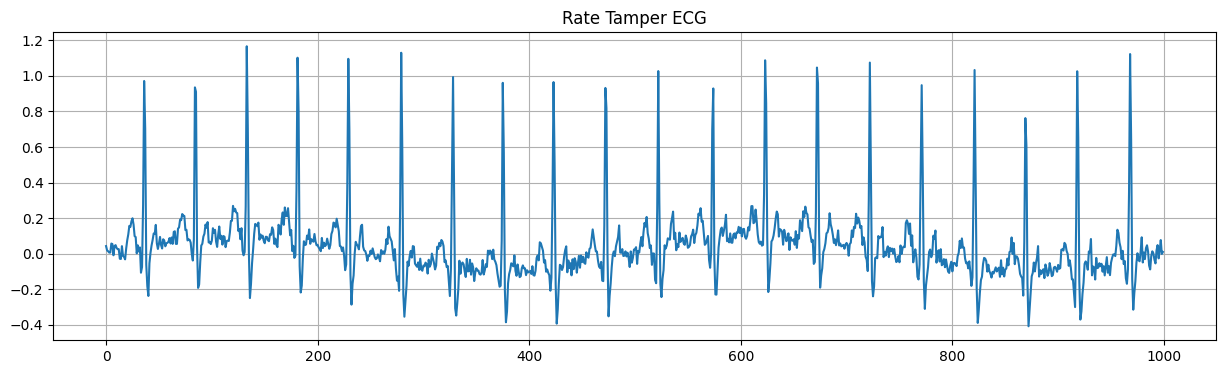

In [51]:
plt.figure(figsize=(15,4))
plt.plot(ecg_normal[:1000])
plt.title("Normal ECG")
plt.grid()
plt.show()

plt.figure(figsize=(15,4))
plt.plot(ecg_rt[:1000])
plt.title("Rate Tamper ECG")
plt.grid()
plt.show()


In [52]:
np.save("normal.npy", ecg_normal)
np.save("ratetamper.npy", ecg_rt)
np.save("injection.npy", ecg_inj)
np.save("replay.npy", ecg_rep)

print("✅ Raw ECG signals saved")


✅ Raw ECG signals saved


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [54]:
ecg_normal = np.load("normal.npy")
ecg_rt     = np.load("ratetamper.npy")
ecg_inj    = np.load("injection.npy")
ecg_rep    = np.load("replay.npy")

print(ecg_normal.shape)


(37500,)


In [55]:
scaler = StandardScaler()

ecg_normal_s = scaler.fit_transform(ecg_normal.reshape(-1,1)).flatten()
ecg_rt_s     = scaler.transform(ecg_rt.reshape(-1,1)).flatten()
ecg_inj_s    = scaler.transform(ecg_inj.reshape(-1,1)).flatten()
ecg_rep_s    = scaler.transform(ecg_rep.reshape(-1,1)).flatten()


In [56]:
WINDOW = 250   # 2 seconds
STRIDE = 125   # 50% overlap


In [57]:
def make_windows(sig, win, stride):
    return np.array([
        sig[i:i+win]
        for i in range(0, len(sig)-win, stride)
    ])


In [58]:
X_norm = make_windows(ecg_normal_s, WINDOW, STRIDE)
X_rt   = make_windows(ecg_rt_s, WINDOW, STRIDE)
X_inj  = make_windows(ecg_inj_s, WINDOW, STRIDE)
X_rep  = make_windows(ecg_rep_s, WINDOW, STRIDE)

print("Normal windows:", X_norm.shape)


Normal windows: (298, 250)


In [59]:
X_train, X_val = train_test_split(
    X_norm, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)


Train: (238, 250)
Val: (60, 250)


In [60]:
X_norm = X_norm[..., np.newaxis]
X_rt   = X_rt[..., np.newaxis]
X_inj  = X_inj[..., np.newaxis]
X_rep  = X_rep[..., np.newaxis]


In [61]:
X_train, X_val = train_test_split(
    X_norm, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)


Train: (238, 250, 1)
Val: (60, 250, 1)


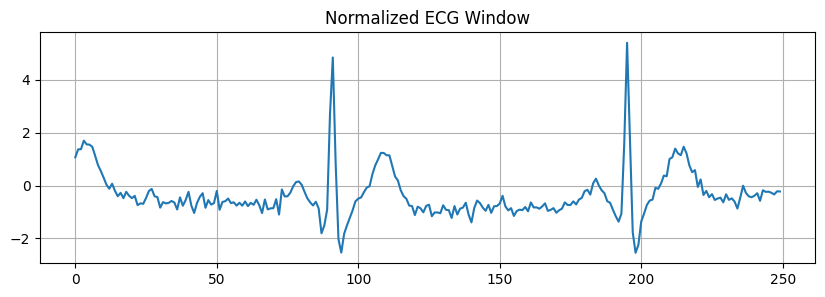

In [62]:
plt.figure(figsize=(10,3))
plt.plot(X_train[0].squeeze())
plt.title("Normalized ECG Window")
plt.grid()
plt.show()


In [63]:
np.save("X_train.npy", X_train)
np.save("X_val.npy", X_val)

np.save("X_test_rt.npy", X_rt)
np.save("X_test_inj.npy", X_inj)
np.save("X_test_rep.npy", X_rep)

print("✅ Preprocessed dataset saved")


✅ Preprocessed dataset saved


In [64]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TF version:", tf.__version__)


TF version: 2.19.0


In [65]:
X_train = np.load("X_train.npy")
X_val   = np.load("X_val.npy")

print("Train:", X_train.shape)
print("Val:", X_val.shape)


Train: (238, 250, 1)
Val: (60, 250, 1)


In [66]:
TIMESTEPS = X_train.shape[1]
FEATURES  = X_train.shape[2]
LATENT_DIM = 32


In [67]:
inputs = Input(shape=(TIMESTEPS, FEATURES))

# Encoder
x = GRU(64, return_sequences=True)(inputs)
x = GRU(32, return_sequences=False)(x)

# Latent representation
latent = Dense(LATENT_DIM, activation="relu")(x)

# Decoder
x = RepeatVector(TIMESTEPS)(latent)
x = GRU(32, return_sequences=True)(x)
x = GRU(64, return_sequences=True)(x)

outputs = TimeDistributed(Dense(FEATURES))(x)

model = Model(inputs, outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 250, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 250, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 250, 32)        │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 250, 64)        │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 250, 1)         │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,545 (189.63 KB)

 Trainable params: 48,545 (189.63 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.compile(
    optimizer="adam",
    loss="mse"
)


In [69]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "gru_ecg_autoencoder.h5",
        monitor="val_loss",
        save_best_only=True
    )
]


In [70]:
history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.9977

2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - loss: 0.9980 - val_loss: 1.0101
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.9965 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.9961 - val_loss: 1.0086
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.9953 - val_loss: 1.0091
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.9967 - val_loss: 1.0097
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.9953 - val_loss: 1.0093
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.9929 - val_loss: 1.0093
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.9919

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.9916 - val_loss: 1.0085
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.9935 - val_loss: 1.0090
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.9846 - val_loss: 1.0103
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.9939

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.9921 - val_loss: 1.0078
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.9761

...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.9170 - val_loss: 0.9331
Epoch 46/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.9129

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 0.9125 - val_loss: 0.9324
Epoch 47/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.9150

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.9136 - val_loss: 0.9293
Epoch 48/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.9098 - val_loss: 0.9298
Epoch 49/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.9046

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - loss: 0.9048 - val_loss: 0.9287
Epoch 50/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.8999

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/step - loss: 0.9014 - val_loss: 0.9279


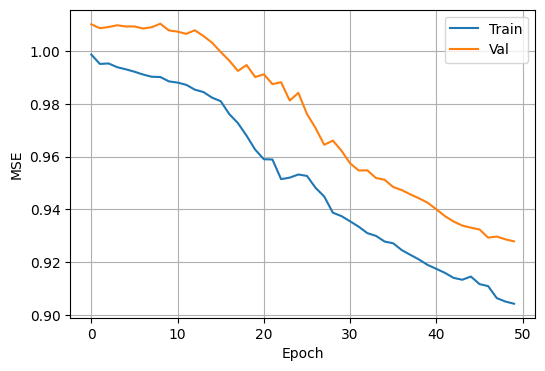

In [71]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.show()


In [ ]:
def reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean((X - X_pred) ** 2, axis=(1,2))


In [ ]:
val_errors = reconstruction_error(model, X_val)

print("Mean error:", val_errors.mean())
print("Std error:", val_errors.std())


In [ ]:
THRESHOLD = np.percentile(val_errors, 95)
print("Anomaly Threshold:", THRESHOLD)


In [ ]:
plt.figure(figsize=(6,4))
plt.hist(val_errors, bins=50)
plt.axvline(THRESHOLD, color="r", linestyle="--", label="Threshold")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.legend()
plt.grid()
plt.show()


In [ ]:
np.save("gru_threshold.npy", THRESHOLD)
print("✅ Threshold saved")


In [ ]:
X_rt  = np.load("X_test_rt.npy")
X_inj = np.load("X_test_inj.npy")
X_rep = np.load("X_test_rep.npy")

threshold = np.load("gru_threshold.npy")


In [ ]:
err_norm = reconstruction_error(model, X_val)
err_rt   = reconstruction_error(model, X_rt)
err_inj  = reconstruction_error(model, X_inj)
err_rep  = reconstruction_error(model, X_rep)


In [ ]:
y_true = np.concatenate([
    np.zeros(len(err_norm)),  # Normal
    np.ones(len(err_rt)),     # Attack
    np.ones(len(err_inj)),
    np.ones(len(err_rep))
])

y_score = np.concatenate([
    err_norm,
    err_rt,
    err_inj,
    err_rep
])


In [ ]:
y_pred = (y_score > threshold).astype(int)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print(cm)

print(classification_report(
    y_true, y_pred,
    target_names=["Normal", "Anomaly"]
))


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()
